<a href="https://colab.research.google.com/github/KIJOTARO/googlecolab/blob/main/copy_of_topicmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTALASI LIBRARY


In [ ]:
!pip install -U pip
!pip install bertopic==0.16.4 sentence-transformers umap-learn hdbscan
!pip install sastrawi nltk emoji wordcloud
!pip install pandas numpy matplotlib seaborn plotly scikit-learn langdetect gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 63.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [emoji]
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 30.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 106.8 MB/s  0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993332 sha256=644bef85bd431ae0acd44eb24c3fe76cc5930a6deef5383f4ae93dc96aa699df
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]


# IMPORT LIBRARY

In [ ]:
import re
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from IPython.display import display

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# LOAD DATASET

In [ ]:
print("📂 Silakan upload file dataset CSV ...")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"✅ File '{file_name}' berhasil diupload")

df = pd.read_csv(io.BytesIO(uploaded[file_name]), engine='python', on_bad_lines='skip')
print(f"✅ Data awal dimuat: {len(df)} baris")

# Validasi kolom utama
if 'full_text' not in df.columns:
    raise ValueError("❌ Kolom 'full_text' tidak ditemukan dalam dataset")
else:
    print("✅ Kolom 'full_text' terdeteksi")

📂 Silakan upload file dataset CSV ...


Saving data-MBG.csv to data-MBG.csv
✅ File 'data-MBG.csv' berhasil diupload
✅ Data awal dimuat: 1116 baris
✅ Kolom 'full_text' terdeteksi


# CASE FOLDING

In [ ]:
df['step_1_case_folding'] = df['full_text'].astype(str).str.lower()

print("🔍 HASIL STEP 1: CASE FOLDING (Semua huruf menjadi kecil)")
display(df[['full_text', 'step_1_case_folding']].head(10))

🔍 HASIL STEP 1: CASE FOLDING (Semua huruf menjadi kecil)


,full_text,step_1_case_folding
0,ujicoba MBG ini telah dilakukan sebelum pelant...,ujicoba mbg ini telah dilakukan sebelum pelant...
1,BGN bergerak cepat! Tim khusus dibentuk untuk ...,bgn bergerak cepat! tim khusus dibentuk untuk ...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen pemerintah diwujudkan melalui penyemp...
3,Badan Gizi Nasional (BGN) menonaktifkan sement...,badan gizi nasional (bgn) menonaktifkan sement...
4,MBG menjadi salah satu program pemerintah yg s...,mbg menjadi salah satu program pemerintah yg s...
5,@sarkasinaja @txtdrimedia Menurutku ini tuh ma...,@sarkasinaja @txtdrimedia menurutku ini tuh ma...
6,Kasus dugaan keracunan dalam program Makan Ber...,kasus dugaan keracunan dalam program makan ber...
7,Proyek Makan Bergizi Gratis Dikuasai Segelinti...,proyek makan bergizi gratis dikuasai segelinti...
8,@velodrone_id @NyaiNeneng @okeh_fik Gibran mel...,@velodrone_id @nyaineneng @okeh_fik gibran mel...
9,Bill Gates Gelontorkan Dana 7-8 Triliun Rupiah...,bill gates gelontorkan dana 7-8 triliun rupiah...


# CLEANING

In [ ]:
def cleaning_process(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Hapus URL
    text = re.sub(r'#\w+|@\w+', '', text)               # Hapus Hashtag & Mention
    text = re.sub(r'\d+', '', text)                    # Hapus Angka
    text = re.sub(r'[^\w\s]', ' ', text)               # Hapus Simbol/Tanda Baca
    text = re.sub(r'\s+', ' ', text).strip()           # Hapus spasi berlebih
    return text

df['step_2_cleaning'] = df['step_1_case_folding'].apply(cleaning_process)

print("🔍 HASIL STEP 2: CLEANING (Pembersihan karakter non-kata)")
display(df[['step_1_case_folding', 'step_2_cleaning']].head(10))

🔍 HASIL STEP 2: CLEANING (Pembersihan karakter non-kata)


,step_1_case_folding,step_2_cleaning
0,ujicoba mbg ini telah dilakukan sebelum pelant...,ujicoba mbg ini telah dilakukan sebelum pelant...
1,bgn bergerak cepat! tim khusus dibentuk untuk ...,bgn bergerak cepat tim khusus dibentuk untuk s...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen pemerintah diwujudkan melalui penyemp...
3,badan gizi nasional (bgn) menonaktifkan sement...,badan gizi nasional bgn menonaktifkan sementar...
4,mbg menjadi salah satu program pemerintah yg s...,mbg menjadi salah satu program pemerintah yg s...
5,@sarkasinaja @txtdrimedia menurutku ini tuh ma...,menurutku ini tuh masalah dapur yg harus bikin...
6,kasus dugaan keracunan dalam program makan ber...,kasus dugaan keracunan dalam program makan ber...
7,proyek makan bergizi gratis dikuasai segelinti...,proyek makan bergizi gratis dikuasai segelinti...
8,@velodrone_id @nyaineneng @okeh_fik gibran mel...,gibran melakukan sidak ke sekolah dalam rangka...
9,bill gates gelontorkan dana 7-8 triliun rupiah...,bill gates gelontorkan dana triliun rupiah unt...


# TOKENISASI

In [ ]:
df['step_3_token'] = df['step_2_cleaning'].apply(lambda x: x.split())

print("🔍 HASIL STEP 3: TOKENISASI (Teks dipecah menjadi list kata)")
display(df[['step_2_cleaning', 'step_3_token']].head(10))

🔍 HASIL STEP 3: TOKENISASI (Teks dipecah menjadi list kata)


,step_2_cleaning,step_3_token
0,ujicoba mbg ini telah dilakukan sebelum pelant...,"[ujicoba, mbg, ini, telah, dilakukan, sebelum,..."
1,bgn bergerak cepat tim khusus dibentuk untuk s...,"[bgn, bergerak, cepat, tim, khusus, dibentuk, ..."
2,komitmen pemerintah diwujudkan melalui penyemp...,"[komitmen, pemerintah, diwujudkan, melalui, pe..."
3,badan gizi nasional bgn menonaktifkan sementar...,"[badan, gizi, nasional, bgn, menonaktifkan, se..."
4,mbg menjadi salah satu program pemerintah yg s...,"[mbg, menjadi, salah, satu, program, pemerinta..."
5,menurutku ini tuh masalah dapur yg harus bikin...,"[menurutku, ini, tuh, masalah, dapur, yg, haru..."
6,kasus dugaan keracunan dalam program makan ber...,"[kasus, dugaan, keracunan, dalam, program, mak..."
7,proyek makan bergizi gratis dikuasai segelinti...,"[proyek, makan, bergizi, gratis, dikuasai, seg..."
8,gibran melakukan sidak ke sekolah dalam rangka...,"[gibran, melakukan, sidak, ke, sekolah, dalam,..."
9,bill gates gelontorkan dana triliun rupiah unt...,"[bill, gates, gelontorkan, dana, triliun, rupi..."


# NORMALISASI

In [ ]:
#1. Load Dataset Kamus Alay (Standar Akademik - nasalsabila)
print("⏳ Sedang mengunduh Kamus Colloquial Indonesian Lexicon...")
url_kamus_alay = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"

try:
    df_kamus = pd.read_csv(url_kamus_alay)
    # Konversi ke dictionary: { 'slang': 'formal' }
    slang_dict_umum = dict(zip(df_kamus['slang'], df_kamus['formal']))
    print(f"✅ Kamus umum berhasil dimuat: {len(slang_dict_umum)} kata.")
except Exception as e:
    print(f"⚠️ Gagal mengunduh kamus online. Menggunakan kamus manual saja. Error: {e}")
    slang_dict_umum = {}

# 2. Definisikan Kamus Khusus (Domain Specific)
# Ini wajib ada untuk menangani istilah baru seperti 'MBG' yang tidak ada di kamus umum
slang_dict_khusus = {
    "mbg": "makan bergizi gratis",
    "bgn": "badan gizi nasional",
    "sppg": "satuan pelayanan pemenuhan gizi",
    "slhs": "standar laik higienis sanitasi",
    "preswapres": "presiden wakil presiden",
    "wapres": "wakil presiden",
    "pilpres": "pemilihan presiden",
    "paslon": "pasangan calon",
    "tps": "tempat pemungutan suara",
    "smt": "semester",
    "sdh": "sudah",
    "udh": "sudah",
    "dgn": "dengan",
    "tdk": "tidak",
    "krn": "karena",
    "yg": "yang"
}

# 3. Gabungkan Kedua Kamus (Hybrid Approach)
# Kamus khusus (kanan) akan menimpa kamus umum (kiri) jika ada kunci yang sama
# Ini penting agar istilah spesifik penelitian Anda diprioritaskan
final_slang_dict = {**slang_dict_umum, **slang_dict_khusus}

print(f"✅ Total kosakata kamus gabungan: {len(final_slang_dict)} kata.")

# 4. Fungsi Normalisasi
def normalize_hybrid(tokens):
    # Cek setiap kata dalam list tokens
    # Jika ada di kamus, ganti dengan bentuk baku. Jika tidak, biarkan apa adanya.
    return [final_slang_dict[word] if word in final_slang_dict else word for word in tokens]

# Terapkan Normalisasi
# Input: step_3_token (list of strings) -> Output: step_4_norm (list of strings)
df['step_4_norm'] = df['step_3_token'].apply(normalize_hybrid)

# Gabungkan kembali jadi kalimat untuk keperluan preview/stemming selanjutnya
df['step_4_str'] = df['step_4_norm'].apply(lambda x: " ".join(x))

print("🔍 HASIL STEP 4: NORMALISASI (Metode Hybrid Dictionary)")
display(df[['step_3_token', 'step_4_str']].head(10))

⏳ Sedang mengunduh Kamus Colloquial Indonesian Lexicon...
✅ Kamus umum berhasil dimuat: 4331 kata.
✅ Total kosakata kamus gabungan: 4340 kata.
🔍 HASIL STEP 4: NORMALISASI (Metode Hybrid Dictionary)


,step_3_token,step_4_str
0,"[ujicoba, mbg, ini, telah, dilakukan, sebelum,...",ujicoba makan bergizi gratis ini telah dilakuk...
1,"[bgn, bergerak, cepat, tim, khusus, dibentuk, ...",badan gizi nasional bergerak cepat tim khusus ...
2,"[komitmen, pemerintah, diwujudkan, melalui, pe...",komitmen pemerintah diwujudkan melalui penyemp...
3,"[badan, gizi, nasional, bgn, menonaktifkan, se...",badan gizi nasional badan gizi nasional menona...
4,"[mbg, menjadi, salah, satu, program, pemerinta...",makan bergizi gratis menjadi salah satu progra...
5,"[menurutku, ini, tuh, masalah, dapur, yg, haru...",menurutku ini tuh masalah dapur yang harus bik...
6,"[kasus, dugaan, keracunan, dalam, program, mak...",kasus dugaan keracunan dalam program makan ber...
7,"[proyek, makan, bergizi, gratis, dikuasai, seg...",proyek makan bergizi gratis dikuasai segelinti...
8,"[gibran, melakukan, sidak, ke, sekolah, dalam,...",gibran melakukan sidak ke sekolah dalam rangka...
9,"[bill, gates, gelontorkan, dana, triliun, rupi...",bill gates gelontorkan dana triliun rupiah unt...


# STEMMING

In [ ]:
print("⏳ Sedang memproses Stemming... Mohon tunggu.")
stemmer = StemmerFactory().create_stemmer()
df['step_5_stemmed'] = df['step_4_str'].apply(lambda x: stemmer.stem(x))

print("🔍 HASIL STEP 5: STEMMING (Kembali ke kata dasar)")
display(df[['step_4_str', 'step_5_stemmed']].head(10))

⏳ Sedang memproses Stemming... Mohon tunggu.
🔍 HASIL STEP 5: STEMMING (Kembali ke kata dasar)


,step_4_str,step_5_stemmed
0,ujicoba makan bergizi gratis ini telah dilakuk...,ujicoba makan gizi gratis ini telah laku belum...
1,badan gizi nasional bergerak cepat tim khusus ...,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional menona...,badan gizi nasional badan gizi nasional nonakt...
4,makan bergizi gratis menjadi salah satu progra...,makan gizi gratis jadi salah satu program peri...
5,menurutku ini tuh masalah dapur yang harus bik...,turut ini tuh masalah dapur yang harus bikin m...
6,kasus dugaan keracunan dalam program makan ber...,kasus duga racun dalam program makan gizi grat...
7,proyek makan bergizi gratis dikuasai segelinti...,proyek makan gizi gratis asai gelintir orang g...
8,gibran melakukan sidak ke sekolah dalam rangka...,gibran laku sidak ke sekolah dalam rangka tinj...
9,bill gates gelontorkan dana triliun rupiah unt...,bill gates gelontor dana triliun rupiah untuk ...


# STOPWORDS REMOVAL

In [ ]:
factory = StopWordRemoverFactory()
stopwords_indonesia = set(factory.get_stop_words())

# Daftar kata tambahan (Slang/Gaul) yang harus dihapus
custom_stopwords = {
    "gue", "lu", "elo", "gw", "lo", "aku", "saya", "kamu", "kita",
    "tuh", "tu", "ga", "gak", "nggak", "enggak", "sih", "si", "nih",
    "ni", "mah", "dong", "kok", "yah", "deh", "dah", "aja", "saja",
    "udah", "sdh", "udh", "blm", "belum", "kalo", "klo", "kalau",
    "tp", "tapi", "yg", "yang", "dan", "di", "itu", "ini", "ke", "dari",
    "bgt", "banget", "utk", "untuk", "dg", "dgn", "dengan", "bisa",
    "mau", "akan", "ada", "pada", "secara", "saat", "juga", "kan"
}
final_stopwords = stopwords_indonesia.union(custom_stopwords)

def remove_stop(text):
    return " ".join([word for word in text.split() if word not in final_stopwords])

df['step_6_final'] = df['step_5_stemmed'].apply(remove_stop)

print("🔍 HASIL STEP 6: STOPWORD REMOVAL (Teks Final Siap Olah)")
display(df[['step_5_stemmed', 'step_6_final']].head(10))


🔍 HASIL STEP 6: STOPWORD REMOVAL (Teks Final Siap Olah)


,step_5_stemmed,step_6_final
0,ujicoba makan gizi gratis ini telah laku belum...,ujicoba makan gizi gratis laku lantik presiden...
1,badan gizi nasional gerak cepat tim khusus ben...,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen perintah wujud lalu sempurna lanjut p...,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional nonakt...,badan gizi nasional badan gizi nasional nonakt...
4,makan gizi gratis jadi salah satu program peri...,makan gizi gratis jadi salah satu program peri...
5,turut ini tuh masalah dapur yang harus bikin m...,turut masalah dapur bikin makan gizi gratis bu...
6,kasus duga racun dalam program makan gizi grat...,kasus duga racun program makan gizi gratis mak...
7,proyek makan gizi gratis asai gelintir orang g...,proyek makan gizi gratis asai gelintir orang g...
8,gibran laku sidak ke sekolah dalam rangka tinj...,gibran laku sidak sekolah rangka tinjau progra...
9,bill gates gelontor dana triliun rupiah untuk ...,bill gates gelontor dana triliun rupiah progra...


# DATASET FINAL

In [ ]:
df_final = df[df['step_6_final'].astype(str).str.len() > 5].copy()
df_final = df_final.reset_index(drop=True)

documents = df_final['step_6_final'].tolist()

print("==========================================")
print(f"✅ Dokumen siap analisis: {len(documents)}")
print("==========================================")
# Jika len(documents) adalah 0, artinya filter terlalu ketat atau proses sebelumnya kosong.
if len(documents) == 0:
    print("❌ ERROR: Dokumen kosong. Periksa kembali proses Stopword/Stemming.")
else:
    display(df_final[['step_6_final']].head(5))

✅ Dokumen siap analisis: 1116


,step_6_final
0,ujicoba makan gizi gratis laku lantik presiden...
1,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional nonakt...
4,makan gizi gratis jadi salah satu program peri...


# WORDCLOUD

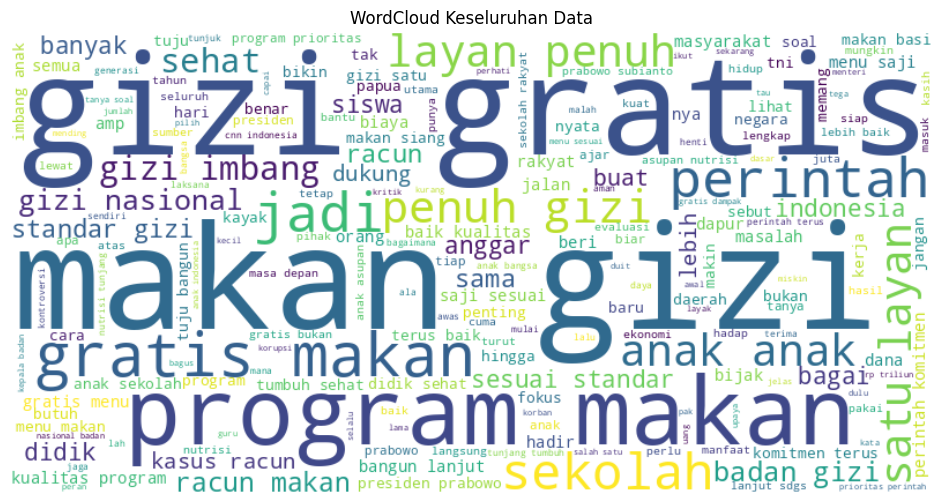

In [ ]:
all_text = " ".join(documents)
if len(all_text.strip()) > 0:
    wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud Keseluruhan Data")
    plt.show()

# PEMODELAN TOPIK - BERTopic

In [ ]:
print("⏳ Sedang memuat model Embedding Multilingual...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
vectorizer_model = CountVectorizer(ngram_range=(1, 2), min_df=2)

hdbscan_model = HDBSCAN(
    min_cluster_size=5,       # Ubah ke 5-10 tergantung jumlah data
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

print("🚀 Melatih Model BERTopic...")
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    representation_model=KeyBERTInspired(),
    nr_topics=7,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents)
df_final['topic'] = topics

# Tampilkan Info Topik
print("\n✅ Pemodelan Selesai. Berikut Daftar Topik:")

⏳ Sedang memuat model Embedding Multilingual...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-02-13 04:58:56,073 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 Melatih Model BERTopic...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

2026-02-13 04:59:31,566 - BERTopic - Embedding - Completed ✓
2026-02-13 04:59:31,568 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-13 04:59:43,781 - BERTopic - Dimensionality - Completed ✓
2026-02-13 04:59:43,782 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-13 04:59:43,869 - BERTopic - Cluster - Completed ✓
2026-02-13 04:59:43,870 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-02-13 05:00:12,324 - BERTopic - Representation - Completed ✓
2026-02-13 05:00:12,325 - BERTopic - Topic reduction - Reducing number of topics
2026-02-13 05:00:16,288 - BERTopic - Topic reduction - Reduced number of topics from 81 to 7



✅ Pemodelan Selesai. Berikut Daftar Topik:


# HASIL TOPIK

In [ ]:
topic_info = topic_model.get_topic_info()
display(topic_info)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,165,-1_gratis makan_makan gratis_program makan_giz...,"[gratis makan, makan gratis, program makan, gi...",[makan gizi gratis makan gizi gratis kali maka...
1,0,505,0_program makan_makan sehat_gratis makan_menu ...,"[program makan, makan sehat, gratis makan, men...",[asupan nutrisi tunjang tumbuh sehat anak anak...
2,1,342,1_gratis makan_presiden prabowo_gratis preside...,"[gratis makan, presiden prabowo, gratis presid...",[presiden prabowo subianto panggil kepala bada...
3,2,50,2_sekolah rakyat_sekolah daya_lingkung sekolah...,"[sekolah rakyat, sekolah daya, lingkung sekola...",[rapbn perintah alokasi rp triliun didik naik ...
4,3,40,3_daya saing_ekonomi rakyat_lanjut sdgs_ekonomi,"[daya saing, ekonomi rakyat, lanjut sdgs, ekon...",[pertamina lalu program bina laku umkm jadi ek...
5,4,7,4_racun program_publik_informasi_gizi nasional,"[racun program, publik, informasi, gizi nasion...",[badan gizi nasional gerak cepat tim khusus be...
6,5,7,5_vitamin mineral_nutrisi baik_vitamin_kandung...,"[vitamin mineral, nutrisi baik, vitamin, kandu...",[dokter spesialis gizi klinik a yasmin syauki ...


# VISUALISASI

In [ ]:
# Barchart
fig_bar = topic_model.visualize_barchart()
fig_bar.show()

# Distance Map
fig_dist = topic_model.visualize_topics()
fig_dist.show()

# WORDCLOUD PER TOPIK

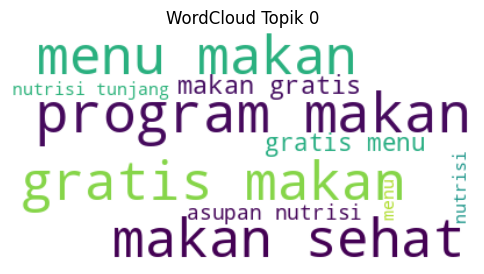

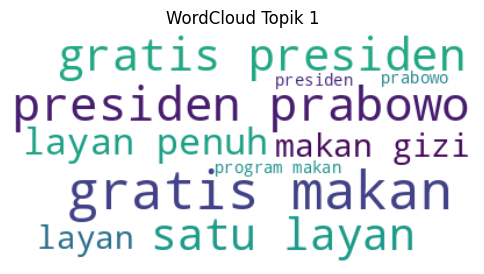

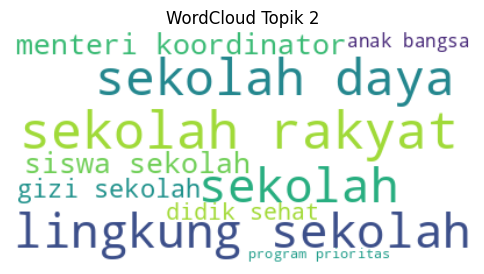

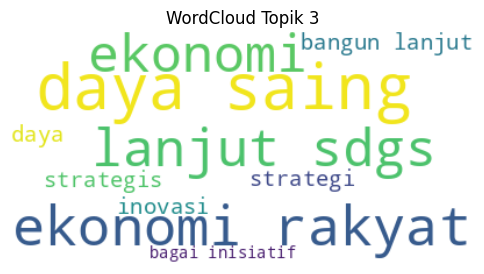

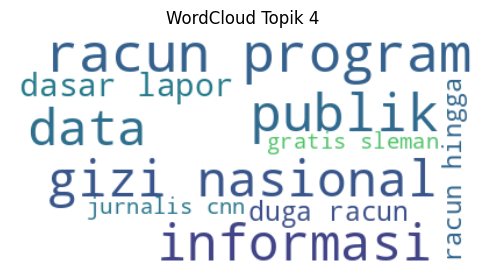

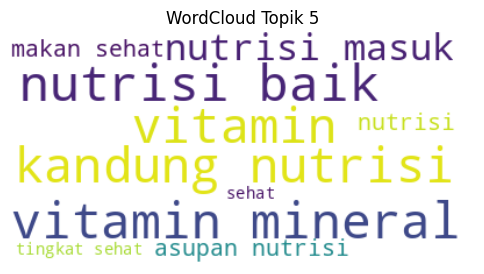

In [ ]:
for t in topic_info.Topic:
    if t == -1: continue # Lewati outlier
    words = dict(topic_model.get_topic(t))
    wc = WordCloud(background_color="white").generate_from_frequencies(words)
    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Topik {t}")
    plt.show()

# EVALUASI KOHERENSI


🚀 MEMBUAT GRAFIK GARIS KOHERENSI PER TOPIK
⏳ Menyiapkan data dan menghitung skor...
✅ Skor Rata-rata Model: 0.7649

📊 MENGGAMBAR GRAFIK GARIS...


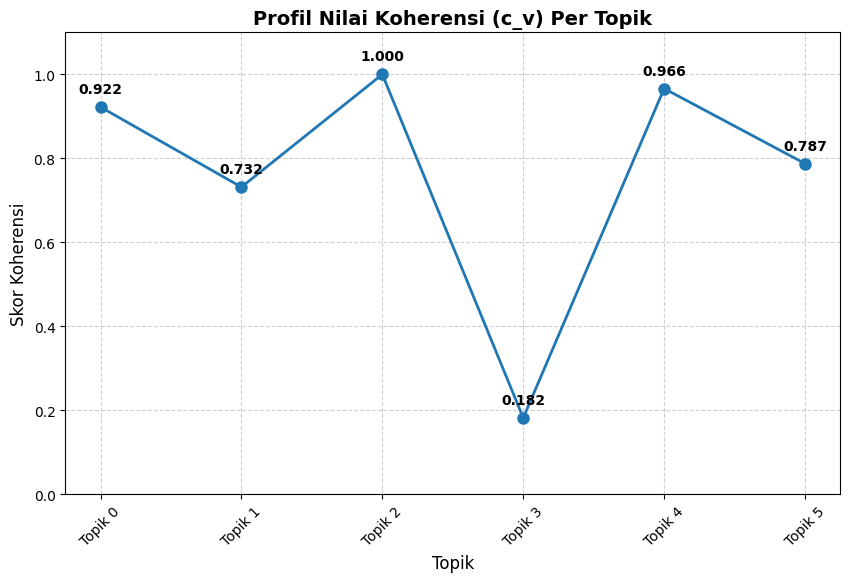

In [ ]:
print("\n" + "="*50)
print("🚀 MEMBUAT GRAFIK GARIS KOHERENSI PER TOPIK")
print("="*50)

# 1. PERSIAPAN DATA (Menggunakan variabel 'documents' yang sudah ada)
print("⏳ Menyiapkan data dan menghitung skor...")

# Tokenisasi ulang data untuk perhitungan Gensim
texts_tokenized = [doc.split() for doc in documents]
dictionary = Dictionary(texts_tokenized)
dictionary.filter_extremes(no_below=2, no_above=0.8)

# 2. AMBIL DATA TOPIK DARI MODEL
# Mengambil info topik (Topik 0 s.d 5)
topic_info_df = topic_model.get_topic_info()
valid_topics = [t for t in topic_info_df['Topic'] if t != -1]

topic_words = []
topic_labels = []

for t in valid_topics:
    # Ambil kata kunci dari model yang sudah dilatih
    words = [w for w, _ in topic_model.get_topic(t)]
    topic_words.append(words)
    topic_labels.append(f"Topik {t}")

# 3. HITUNG KOHERENSI (c_v)
if topic_words:
    cm = CoherenceModel(
        topics=topic_words,
        texts=texts_tokenized,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_per_topic = cm.get_coherence_per_topic()
    global_score = cm.get_coherence()
else:
    coherence_per_topic = []
    global_score = 0

print(f"✅ Skor Rata-rata Model: {global_score:.4f}")

# 4. PLOT GRAFIK GARIS (LINE CHART)
print("\n📊 MENGGAMBAR GRAFIK GARIS...")
plt.figure(figsize=(10, 6))

# Plot Garis dengan Marker Bulat
plt.plot(topic_labels, coherence_per_topic, marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=8)

# Menambahkan Label Angka di setiap titik
for i, txt in enumerate(coherence_per_topic):
    plt.annotate(f"{txt:.3f}",
                 (topic_labels[i], coherence_per_topic[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center',
                 fontweight='bold',
                 fontsize=10)

# Hiasan Grafik
plt.title('Profil Nilai Koherensi (c_v) Per Topik', fontsize=14, fontweight='bold')
plt.xlabel('Topik', fontsize=12)
plt.ylabel('Skor Koherensi', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Simpan Grafik Sementara
nama_grafik = "grafik_garis_koherensi.png"
plt.savefig(nama_grafik, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import os
import shutil
import pandas as pd
from google.colab import drive

print("💾 MEMULAI PENYIMPANAN DATA ")
drive.mount('/content/drive')

# 1. BUAT FOLDER PENYIMPANAN
save_path = '/content/drive/MyDrive/Skripsi_Nanda'
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"✅ Folder Siap: {save_path}")

try:
    # 2. SIMPAN MODEL (Wajib Format Safetensors agar ringan di Streamlit)
    # save_ctfidf=True penting agar visualisasi barchart jalan
    topic_model.save(f"{save_path}/my_bertopic_model", serialization="safetensors", save_ctfidf=True)
    print("✅ [1/5] Model BERTopic tersimpan (Format Safetensors).")

    # 3. SIMPAN DATASET TWEET
    # Pastikan kolom Topic ada
    if 'Topic' not in df_final.columns:
        df_final['Topic'] = topic_model.topics_
    df_final.to_csv(f"{save_path}/data_hasil_topik.csv", index=False)
    print("✅ [2/5] File CSV Data Utama tersimpan.")

    # 4. SIMPAN INFO TOPIK + SKOR KOHERENSI
    # Kita gabungkan skor koherensi ke dalam file ini agar Streamlit tidak perlu hitung ulang (berat)
    topic_info_df = topic_model.get_topic_info()

    # Cek apakah variabel skor koherensi tersedia di memori
    if 'coherence_per_topic' in globals() and 'valid_topics' in globals():
        try:
            df_skor = pd.DataFrame({'Topic': valid_topics, 'Coherence_Score': coherence_per_topic})
            topic_info_df = topic_info_df.merge(df_skor, on='Topic', how='left')
            print("   ℹ️ Skor koherensi berhasil digabung ke CSV Info.")
        except:
            print("   ⚠️ Gagal menggabung skor koherensi (Mungkin jumlah baris beda), menyimpan info standar.")

    topic_info_df.to_csv(f"{save_path}/info_topik_lengkap.csv", index=False)
    print("✅ [3/5] File CSV Info Topik tersimpan.")

    # 5. SIMPAN GRAFIK LOLLIPOP (Aset Visual)
    nama_grafik = "grafik_lollipop_koherensi.png"
    if os.path.exists(nama_grafik):
        shutil.copy(nama_grafik, f"{save_path}/{nama_grafik}")
        print("✅ [4/5] Gambar Grafik tersimpan.")


    req_text = """streamlit
pandas
bertopic
plotly
matplotlib
scikit-learn
sastrawi
wordcloud
safetensors
"""
    with open(f"{save_path}/requirements.txt", "w") as f:
        f.write(req_text)
    print("✅ [5/5] File 'requirements.txt' berhasil dibuat otomatis.")

    print("\n" + "="*50)
    print(f" SELESAI! File tersimpan : {save_path}")
    print("="*50)

except Exception as e:
    print(f"\n❌ TERJADI ERROR SAAT MENYIMPAN: {e}")